In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


df_full = pd.read_csv('data_appl_cleaned.csv')

In [ ]:
# Moneyness = 1.0 -> ATM, >1.0 -> ITM, <1.0 -> OTM
df_full['Moneyness'] = df_full['UNDERLYING_LAST'] / df_full['STRIKE']
df_full['T_years'] = df_full['DTE'] / 365.0

df_full['diff_pct'] = abs(df_full['UNDERLYING_LAST'] - df_full['STRIKE']) / df_full['UNDERLYING_LAST']

required_cols = ['vol_garch', 'UNDERLYING_LAST', 'C_LAST', 'Moneyness']
df_full = df_full.dropna(subset=required_cols)

print(f"Тренуємо модель на повному датасеті data_appl_cleaned. Всього записів: {len(df_full)}")

Тренуємо модель на повному датасеті data_appl_cleaned. Всього записів: 774128


In [ ]:
# Вчимо модель на всьому: Ціна, Час, Волатильність, Грошовість (Moneyness)
feature_cols = ['UNDERLYING_LAST', 'T_years', 'vol_garch', 'Moneyness']
target_col = ['C_LAST']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_full[feature_cols])
y_scaled = scaler_y.fit_transform(df_full[target_col])

# Спліт 60/20/20 (без перемішування)
n = len(df_full)
train_idx = int(n * 0.6)
val_idx = int(n * 0.8)

X_train = X_scaled[:train_idx]
y_train = y_scaled[:train_idx]
X_val = X_scaled[train_idx:val_idx]
y_val = y_scaled[train_idx:val_idx]
X_test = X_scaled[val_idx:]
y_test = y_scaled[val_idx:]

X_train_lstm = X_train.reshape((X_train.shape[0], 1, len(feature_cols)))
X_val_lstm = X_val.reshape((X_val.shape[0], 1, len(feature_cols)))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, len(feature_cols)))

Починаємо тренування...
Epoch 1/100
7242/7258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - mae: 0.0259
Epoch 1: val_loss improved from None to 0.00060, saving model to best_atm_model.keras
7258/7258 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.0010 - mae: 0.0170 - val_loss: 6.0011e-04 - val_mae: 0.0139
Epoch 2/100
7234/7258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8623e-04 - mae: 0.0141
Epoch 2: val_loss improved from 0.00060 to 0.00059, saving model to best_atm_model.keras
7258/7258 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 5.7582e-04 - mae: 0.0140 - val_loss: 5.9152e-04 - val_mae: 0.0145
Epoch 3/100
7251/7258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5996e-04 - mae: 0.0137
Epoch 3: val_loss improved from 0.00059 to 0.00052, saving model to best_atm_model.keras
7258/7258 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 5.5698e-04 - mae: 0.0136 - val_loss: 5.1783e-04 - val_mae: 0.0126
Epoch 4/100
7241/7258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.4930e-04 - mae: 0.0135
Epoch 4: val_l

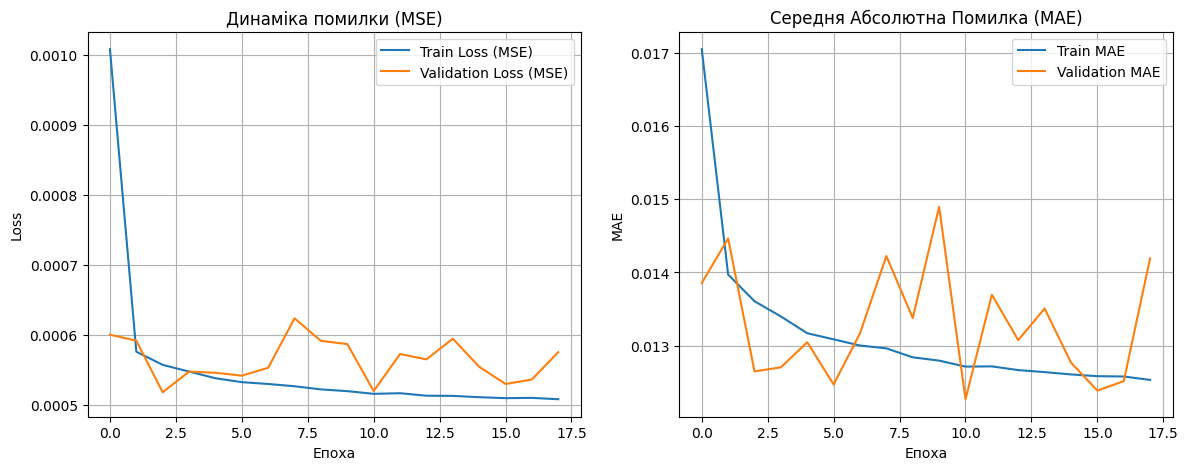

Найкращу модель збережено у файл 'best_atm_model.keras'


In [ ]:
model = Sequential()
model.add(Input(shape=(1, len(feature_cols))))
model.add(LSTM(128, activation='tanh', return_sequences=False)) 
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1)) 

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    filepath='best_atm_model.keras',  
    monitor='val_loss',               
    save_best_only=True,              
    mode='min',                       
    verbose=1                         
)

logger = CSVLogger('training_log.csv', append=True)

print("Починаємо тренування...")
history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, checkpoint, logger], 
    validation_data=(X_val_lstm, y_val),
    verbose=1
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Динаміка помилки (MSE)')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Середня Абсолютна Помилка (MAE)')
plt.xlabel('Епоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.show()

print("Найкращу модель збережено у файл 'best_atm_model.keras'")

Аналізуємо Страйк 125.0 за 2021 рік...
✅ Знайдено найкращу дату для аналізу: 2021-09-23
Кількість точок (термінів експірації): 20
Ціна активу в цей день: 146.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


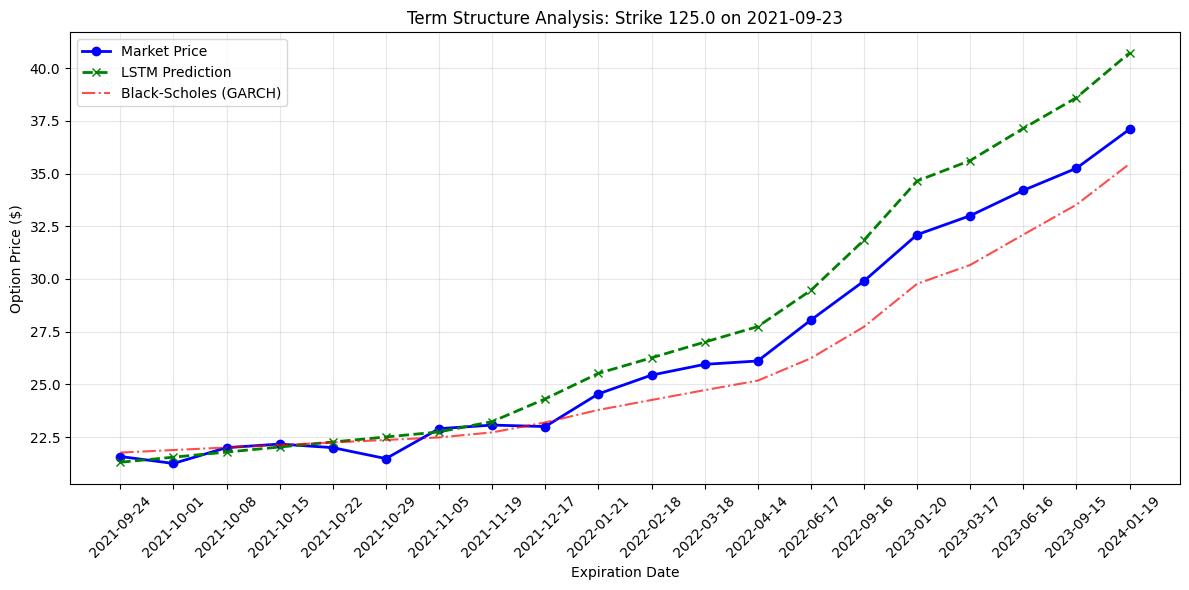

In [9]:
TARGET_STRIKE = 125.0
TARGET_YEAR = 2021

print(f"Аналізуємо Страйк {TARGET_STRIKE} за {TARGET_YEAR} рік...")
best_model = load_model('best_atm_model.keras')

df_analyze = df_full.copy()

df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['STRIKE'] == TARGET_STRIKE) & (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR)
df_subset = df_analyze[mask].copy()

if len(df_subset) == 0:
    print("❌ Даних для цього страйку в цьому році не знайдено.")
else:
    best_date = df_subset.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data = df_subset[df_subset['QUOTE_DATE'] == best_date].sort_values(col_expire)

    print(f"✅ Знайдено найкращу дату для аналізу: {best_date.date()}")
    print(f"Кількість точок (термінів експірації): {len(plot_data)}")
    print(f"Ціна активу в цей день: {plot_data['UNDERLYING_LAST'].iloc[0]}")

    X_plot = scaler_X.transform(plot_data[feature_cols])
    X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

    RISK_FREE_RATE = 0.05
    def bs_calc(row):
        S = row['UNDERLYING_LAST']; K = row['STRIKE']
        T = row['T_years']; sigma = row['vol_garch']
        if T<=0 or sigma<=0: return max(S-K, 0)
        d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

    bs_preds = plot_data.apply(bs_calc, axis=1)

    plt.figure(figsize=(12, 6))

    x_dates = plot_data[col_expire].dt.strftime('%Y-%m-%d')

    plt.plot(x_dates, plot_data['C_LAST'], label='Market Price', marker='o', color='blue', linewidth=2)
    plt.plot(x_dates, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green', linewidth=2)
    plt.plot(x_dates, bs_preds, label='Black-Scholes (GARCH)', linestyle='-.', color='red', alpha=0.7)

    plt.title(f'Term Structure Analysis: Strike {TARGET_STRIKE} on {best_date.date()}')
    plt.xlabel('Expiration Date')
    plt.ylabel('Option Price ($)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Шукаємо ідеальний ATM сценарій у 2021 році...
✅ Дата з найкращим покриттям ATM: 2021-02-25
💰 Ціна активу в цей день: 121.0
🎯 ATM Страйк: 120.0
📊 Кількість точок на графіку: 18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


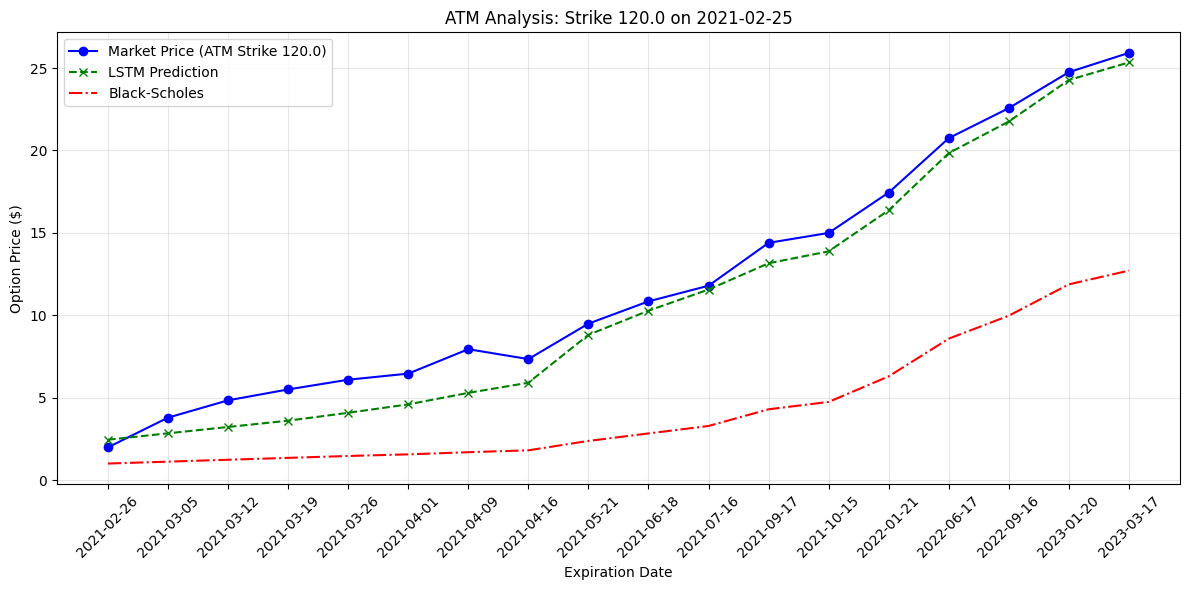

In [ ]:
TARGET_YEAR = 2021
print(f"Шукаємо ідеальний ATM сценарій у {TARGET_YEAR} році...")

best_model = load_model('best_atm_model.keras')
df_analyze = df_full.copy()

df_analyze['QUOTE_DATE'] = pd.to_datetime(df_analyze['QUOTE_DATE'])
col_expire = 'EXPIRE_DATE' if 'EXPIRE_DATE' in df_analyze.columns else 'EXPIRATION_DATE'
df_analyze[col_expire] = pd.to_datetime(df_analyze[col_expire])

mask = (df_analyze['QUOTE_DATE'].dt.year == TARGET_YEAR) & (df_analyze['diff_pct'] <= 0.01)
df_atm_2021 = df_analyze[mask].copy()

if len(df_atm_2021) == 0:
    print("❌ У 2021 році не знайдено опціонів з точністю ATM 1%. Спробуйте збільшити до 2%.")
else:
    best_date = df_atm_2021.groupby('QUOTE_DATE')['DTE'].count().idxmax()
    
    plot_data = df_atm_2021[df_atm_2021['QUOTE_DATE'] == best_date].sort_values(col_expire)
    
    atm_strike_on_that_day = plot_data['STRIKE'].mode()[0]
    
    plot_data = plot_data[plot_data['STRIKE'] == atm_strike_on_that_day]

    print(f"✅ Дата з найкращим покриттям ATM: {best_date.date()}")
    print(f"💰 Ціна активу в цей день: {plot_data['UNDERLYING_LAST'].iloc[0]}")
    print(f"🎯 ATM Страйк: {atm_strike_on_that_day}")
    print(f"📊 Кількість точок на графіку: {len(plot_data)}")

    X_plot = scaler_X.transform(plot_data[feature_cols])
    X_plot_lstm = X_plot.reshape((X_plot.shape[0], 1, len(feature_cols)))

    lstm_preds = scaler_y.inverse_transform(best_model.predict(X_plot_lstm)).flatten()

    RISK_FREE_RATE = 0.05
    def bs_calc(row):
        S = row['UNDERLYING_LAST']; K = row['STRIKE']
        T = row['T_years']; sigma = row['vol_garch']
        if T<=0 or sigma<=0: return max(S-K, 0)
        d1 = (np.log(S/K) + (RISK_FREE_RATE + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        return S*norm.cdf(d1) - K*np.exp(-RISK_FREE_RATE*T)*norm.cdf(d2)

    bs_preds = plot_data.apply(bs_calc, axis=1)

    plt.figure(figsize=(12, 6))
    x_dates = plot_data[col_expire].dt.strftime('%Y-%m-%d')

    plt.plot(x_dates, plot_data['C_LAST'], label=f'Market Price (ATM Strike {atm_strike_on_that_day})', marker='o', color='blue')
    plt.plot(x_dates, lstm_preds, label='LSTM Prediction', marker='x', linestyle='--', color='green')
    plt.plot(x_dates, bs_preds, label='Black-Scholes', linestyle='-.', color='red')

    plt.title(f'ATM Analysis: Strike {atm_strike_on_that_day} on {best_date.date()}')
    plt.xlabel('Expiration Date')
    plt.ylabel('Option Price ($)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()